**1. Import LIbrary**

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

**2. Load Dataset**

In [41]:
dataset = "diabetes.csv"
df = pd.read_csv(dataset)

print(f"{df.shape[0]} baris (Orang/Pasien)")

df.head()

768 baris (Orang/Pasien)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Visualisasi: Heatmap Korelasi

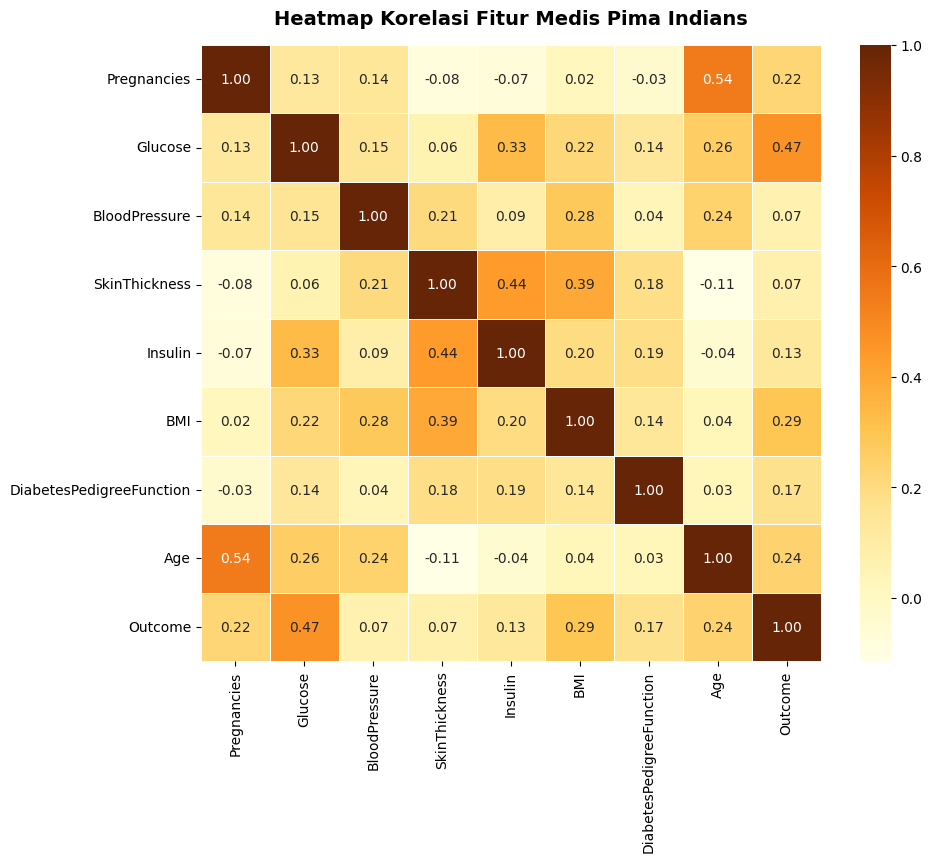

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='YlOrBr', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Medis Pima Indians', fontsize=14, fontweight='bold', pad=15)
plt.show()

**3. Preprocessing**

Pembagian Fitur dan Target Class (Outcome)

In [43]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']

print("x ada 8 kolom Fitur")
print("y ada 1 kolom Target Outcome")

x ada 8 kolom Fitur
y ada 1 kolom Target Outcome


Pembagian Data (Train/Test) dan Feature Scaling

In [44]:
x_train, x_test, y_train, y_test = train_test_split(
x,y, test_size=0.2, random_state=42)

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

print(f"Jumlah data train= {len(x_train_scaled)} data")
print(f"Jumlah data test= {len(x_test_scaled)} data")

print("\n", x_train_scaled[:3].round(2))

Jumlah data train= 614 data
Jumlah data test= 154 data

 [[-0.53 -1.15 -3.75 -1.32 -0.7  -4.14 -0.49 -1.04]
 [ 1.59 -0.28  0.68  0.23 -0.7  -0.49  2.42  1.49]
 [-0.83  0.57 -1.27 -0.09  0.01 -0.42  0.55 -0.95]]


**4. Train KNN dengan 4 Distance Metric dan Variasi K**

In [45]:
hasil_akurasi= {}
models={}

jarak_metrics={
    'Euclidean':{'metric':'euclidean'},
    'Manhattan':{'metric':'manhattan'},
    'Chebyshev':{'metric':'chebyshev'},
    'Minkowski':{'metric':'minkowski', 'p':3}}

variasi_k = [3, 5, 7]

print("Akurasi KNN dengan Variasi K (k=3, k=5, k=7)\n")

for nama, jenis in jarak_metrics.items():
    print(f"{nama}")
    best_acc = 0
    best_k = 0
    best_model = None
    for k in variasi_k:
        knn=KNeighborsClassifier(n_neighbors=k, **jenis).fit(x_train_scaled, y_train)
        acc=accuracy_score(y_test, knn.predict(x_test_scaled))
        print(f"  k={k}: {round(acc * 100, 2)}%")
        if acc > best_acc:
            best_acc = acc
            best_k = k
            best_model = knn
    hasil_akurasi[f'KNN {nama}']=best_acc
    models[f'KNN_{nama}']=best_model
    print(f"Best k={best_k} ({round(best_acc * 100, 2)}%)\n")

tabel_hasil = pd.DataFrame(list(hasil_akurasi.items()), columns=['Model', 'Akurasi'])

Akurasi KNN dengan Variasi K (k=3, k=5, k=7)

Euclidean
  k=3: 70.78%
  k=5: 69.48%
  k=7: 68.18%
Best k=3 (70.78%)

Manhattan
  k=3: 67.53%
  k=5: 66.23%
  k=7: 70.78%
Best k=7 (70.78%)

Chebyshev
  k=3: 61.04%
  k=5: 68.83%
  k=7: 67.53%
Best k=5 (68.83%)

Minkowski
  k=3: 68.83%
  k=5: 70.78%
  k=7: 67.53%
Best k=5 (70.78%)



**5. Decision Tree**

In [46]:
print("Hasil Akurasi Decision Tree\n")

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(x_train_scaled, y_train)

pred_dt = dt_model.predict(x_test_scaled)

akurasi_dt = accuracy_score(y_test, pred_dt)

hasil_akurasi["Decision Tree"] = akurasi_dt
models["Decision Tree"] = dt_model

print("Decision Tree =", round(akurasi_dt * 100, 2), "%")

Hasil Akurasi Decision Tree

Decision Tree = 79.22 %


**6. Ensemble (Majority Voting)**

In [47]:
estimator_list = [
    ('knn_euc', models['KNN_Euclidean']),
    ('knn_man', models['KNN_Manhattan']),
    ('knn_che', models['KNN_Chebyshev']),
    ('knn_min', models['KNN_Minkowski']),
    ('dt', models['Decision Tree'])
]

ensemble_model = VotingClassifier(estimators=estimator_list, voting='hard')
ensemble_model.fit(x_train_scaled, y_train)
prediksi_ensemble = ensemble_model.predict(x_test_scaled)
akurasi_ensemble = accuracy_score(y_test, prediksi_ensemble)
hasil_akurasi['Ensemble (Gabungan)'] = akurasi_ensemble
models['Ensemble'] = ensemble_model
print(f"Tingkat Akurasi Final Gabungan: {round(akurasi_ensemble * 100, 2)} %")

Tingkat Akurasi Final Gabungan: 70.13 %


**7. Perbandingan Model**

In [48]:
tabel_hasil = pd.DataFrame(list(hasil_akurasi.items()), columns=['Model', 'Akurasi'])

tabel_hasil = tabel_hasil.sort_values('Akurasi', ascending=False)
tabel_hasil = tabel_hasil.reset_index(drop=True)
tabel_hasil.index = tabel_hasil.index + 1

display(tabel_hasil)

,Model,Akurasi
1,Decision Tree,0.792208
2,KNN Euclidean,0.707792
3,KNN Manhattan,0.707792
4,KNN Minkowski,0.707792
5,Ensemble (Gabungan),0.701299
6,KNN Chebyshev,0.688312


### Visualisasi: Confusion Matrix

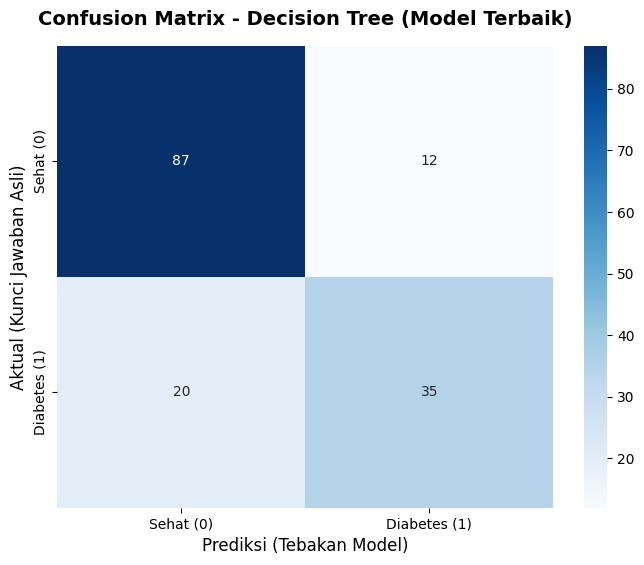

In [49]:
cm = confusion_matrix(y_test, pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sehat (0)', 'Diabetes (1)'],
            yticklabels=['Sehat (0)', 'Diabetes (1)'])
plt.title('Confusion Matrix - Decision Tree (Model Terbaik)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Aktual (Kunci Jawaban Asli)', fontsize=12)
plt.xlabel('Prediksi (Tebakan Model)', fontsize=12)
plt.show()

**8. Simulasi**

Data Pasien Baru

In [50]:
kolom_fitur = x.columns.tolist()

data_pasien_baru = pd.DataFrame(
    [[2, 150, 75, 20, 100, 33.0, 0.5, 40]],
    columns=kolom_fitur)
data_pasien_normal = scaler.transform(data_pasien_baru)

print(f"Data Pasien Berdasarkan Angka Asli / Polos : ", data_pasien_baru.values[0])
print(f"Data Pasien Setelah Angka Konversi : ", data_pasien_normal[0])

Data Pasien Berdasarkan Angka Asli / Polos :  [  2.  150.   75.   20.  100.   33.    0.5  40. ]
Data Pasien Setelah Angka Konversi :  [-0.52639686  0.91052481  0.30191569 -0.02587461  0.1598232   0.13144174
  0.0916066   0.61708663]


Prediksi Voting Ensemble

In [51]:
suara_diabetes =0
suara_sehat =0

for nama, model in models.items():
    if nama != 'Ensemble':
        hasil_prediksi = model.predict(data_pasien_normal) [0]
        if hasil_prediksi ==1:
            suara_diabetes +=1
            print (f"Berdasarkan {nama} : 1 (Pasien Diabetes)")
        else:
            suara_sehat +=1
            print (f"Berdasarkan {nama} : 0 (Pasien Sehat)")

Berdasarkan KNN_Euclidean : 1 (Pasien Diabetes)
Berdasarkan KNN_Manhattan : 1 (Pasien Diabetes)
Berdasarkan KNN_Chebyshev : 1 (Pasien Diabetes)
Berdasarkan KNN_Minkowski : 1 (Pasien Diabetes)
Berdasarkan Decision Tree : 1 (Pasien Diabetes)


Hasil & Kesimpulan

In [52]:
print (f"Terdapat {suara_diabetes} algoritma yang menyatakan bahwa pasien terkena diabetes.")

if suara_diabetes >=3:
    print ("Maka dengan ini dinyatakan bahwa pasien harus segera mendapat perawatan medis.")
else:
    print ("Maka dengan ini dinyatakan bahwa pasien bebas terhadap diabetes.")

Terdapat 5 algoritma yang menyatakan bahwa pasien terkena diabetes.
Maka dengan ini dinyatakan bahwa pasien harus segera mendapat perawatan medis.
